# VDJBet YF Analysis (Rmd-aligned)

Python rewrite of `tmp/vdjbet_snippet.Rmd` with matching analysis outputs:

1. YF vs OLGA V-usage and V/J correction factors
2. LLW reference and adjusted mock generation
3. LLW Pgen histogram match against mock bins
4. LLW overlap per sample: matched clonotypes and duplicate_count
5. Cohen d, z-scores, empirical p-values, FDR
6. Red line (LLW) + mock boxplots and Cohen d heatmaps

In [1]:
# Remove stale control locks left by killed processes before any control builds.
import os, signal
from pathlib import Path

_locks_dir = Path.home() / '.cache' / 'mirpy' / 'controls' / '.locks'
if _locks_dir.exists():
    for _lf in sorted(_locks_dir.glob('*.lock')):
        try:
            _pid = int(_lf.read_text().split('pid=')[1].split()[0])
            try:
                os.kill(_pid, 0)   # process still alive — keep lock
            except (ProcessLookupError, PermissionError):
                _lf.unlink(missing_ok=True)
                print(f'Removed stale lock: {_lf.name} (pid={_pid} dead)')
        except Exception:
            pass
print('Lock check done.')


Lock check done.


In [2]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

import math
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.comparative.vdjbet_workflow import (
    bh_fdr,
    build_real_control_analysis,
    build_synthetic_comparison,
    compute_bin_alignment_diagnostics,
    compute_olga_usage_adjustment,
    load_yfv_trb_samples,
    score_samples_dataframe,
)
from mir.common.parser import load_vdjdb_latest
from mir.utils.notebook_assets import ensure_airr_yfv19, notebook_large_assets_root

SEED = 42
N_MOCKS = 1000
POOL_SIZE = 100_000
OLGA_USAGE_N = 1_000_000
# count_rearrangement (default, unweighted) or count_duplicates (weighted by duplicate_count)
USAGE_COUNT_MODE = "count_rearrangement"
USAGE_PSEUDOCOUNT = 1.0
YFV_CACHE_DIRNAME = "pkl_trb_repertoires"

ASSET_ROOT = notebook_large_assets_root(repo_root)
YFV_DIR = ensure_airr_yfv19(repo_root)

print(f"YFV_DIR = {YFV_DIR}")
print(f"ASSET_ROOT = {ASSET_ROOT}")
print(f"Usage mode = {USAGE_COUNT_MODE}, pseudocount = {USAGE_PSEUDOCOUNT}")
print(f"OLGA usage cache size = {OLGA_USAGE_N:,}")
print(f"N_MOCKS = {N_MOCKS}")

# Publication-quality matplotlib style (Nature/Science aesthetics)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
})

Python 3.12.12
  mirpy-lib: 1.1.0
  numpy: 1.26.4
  pandas: 3.0.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.40.1


/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


YFV_DIR = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_yfv19
ASSET_ROOT = /Users/mikesh/vcs/mirpy/notebooks/assets/large
Usage mode = count_rearrangement, pseudocount = 1.0
OLGA usage cache size = 1,000,000
N_MOCKS = 1000


## 1. Load LLWNGPMAV TRB reference from VDJdb

In [3]:
vdjdb_rep = load_vdjdb_latest(
    epitope="LLWNGPMAV",
    locus="TRB",
    species="HomoSapiens",
    mhc_a_contains="A*02",
)
print(f"Reference clonotypes: {vdjdb_rep.clonotype_count}")
if vdjdb_rep.clonotype_count > 0:
    print(f"Example: {vdjdb_rep.clonotypes[0].junction_aa}  {vdjdb_rep.clonotypes[0].v_gene}  {vdjdb_rep.clonotypes[0].j_gene}")
else:
    print("Warning: no clonotypes returned for this epitope/allele in VDJdb. Downstream cells may fail.")

Downloading: https://github.com/antigenomics/vdjdb-db/releases/download/2026-05-16/vdjdb-2026-05-16.zip


LLWNGPMAV: 409 unique TRB clonotypes
Reference clonotypes: 409
Example: CAIQDAGASYEQYF  TRBV6-2*01  TRBJ2-7*01


## 2. Load YF samples

In [4]:
# Load YF TRB repertoires and build per-sample records for VDJBet.
warnings.filterwarnings("ignore", category=FutureWarning)

samples, yfv_gu = load_yfv_trb_samples(YFV_DIR)

print(f"Loaded TRB samples: {len(samples)}")
print(f"Total TRB clonotypes: {sum(s['repertoire'].clonotype_count for s in samples):,}")
print(f"Total TRB duplicates: {sum(s['repertoire'].duplicate_count for s in samples):,}")

Loaded TRB samples: 42
Total TRB clonotypes: 29,939,151
Total TRB duplicates: 56,732,204


## 3. OLGA usage and correction factors

Compute OLGA and YF usage frequencies, then derive correction factors.

Frequencies are computed in GeneUsage with configurable count mode and Laplace smoothing:

- mode count_rearrangement: count of unique clonotypes per key / total clonotypes
- mode count_duplicates: sum duplicate_count per key / total duplicate_count
- pseudocount 1 is added for both YF and OLGA sides

Formulas:

- factor_v = P_YF(V) / P_OLGA(V)
- factor_vj = P_YF(V,J) / P_OLGA(V,J)

These factors are used by PgenGeneUsageAdjustment.

Top V genes by |log2 factor|:


,v_gene,p_yf,p_olga,factor_v,log2_factor_v,abs_log2
42,TRBV7-4,0.000514,0.012933,0.039769,-4.652226,4.652226
34,TRBV6-3,0.000602,0.011130,0.054079,-4.208799,4.208799
38,TRBV6-8,0.000327,0.002943,0.111047,-3.170758,3.170758
39,TRBV6-9,0.000210,0.001774,0.118152,-3.081285,3.081285
0,TRBV10-1,0.003474,0.027168,0.127878,-2.967164,2.967164
9,TRBV13,0.004602,0.033953,0.135543,-2.883182,2.883182
35,TRBV6-4,0.004885,0.035428,0.137887,-2.858442,2.858442
5,TRBV11-3,0.004155,0.020195,0.205763,-2.280945,2.280945
6,TRBV12-3,0.071966,0.016474,4.368434,2.127116,2.127116
8,TRBV12-5,0.003422,0.012931,0.264602,-1.918104,1.918104


Top VJ pairs by |log2 factor|:


,v_gene,j_gene,p_yf,p_olga,factor_vj,log2_factor_vj,abs_log2
565,TRBV7-4,TRBJ1-2,0.000024,0.001272,0.018877,-5.727231,5.727231
71,TRBV11-3,TRBJ1-5,0.000054,0.002093,0.025665,-5.284056,5.284056
575,TRBV7-4,TRBJ2-6,0.000006,0.000204,0.027196,-5.200448,5.200448
564,TRBV7-4,TRBJ1-1,0.000040,0.001453,0.027859,-5.165700,5.165700
473,TRBV6-4,TRBJ1-3,0.000030,0.001063,0.028051,-5.155828,5.155828
474,TRBV6-4,TRBJ1-4,0.000049,0.001615,0.030113,-5.053479,5.053479
567,TRBV7-4,TRBJ1-4,0.000019,0.000608,0.030893,-5.016563,5.016563
462,TRBV6-3,TRBJ1-5,0.000039,0.001222,0.032083,-4.962054,4.962054
569,TRBV7-4,TRBJ1-6,0.000015,0.000437,0.033728,-4.889917,4.889917
124,TRBV13,TRBJ1-5,0.000127,0.003639,0.034826,-4.843677,4.843677


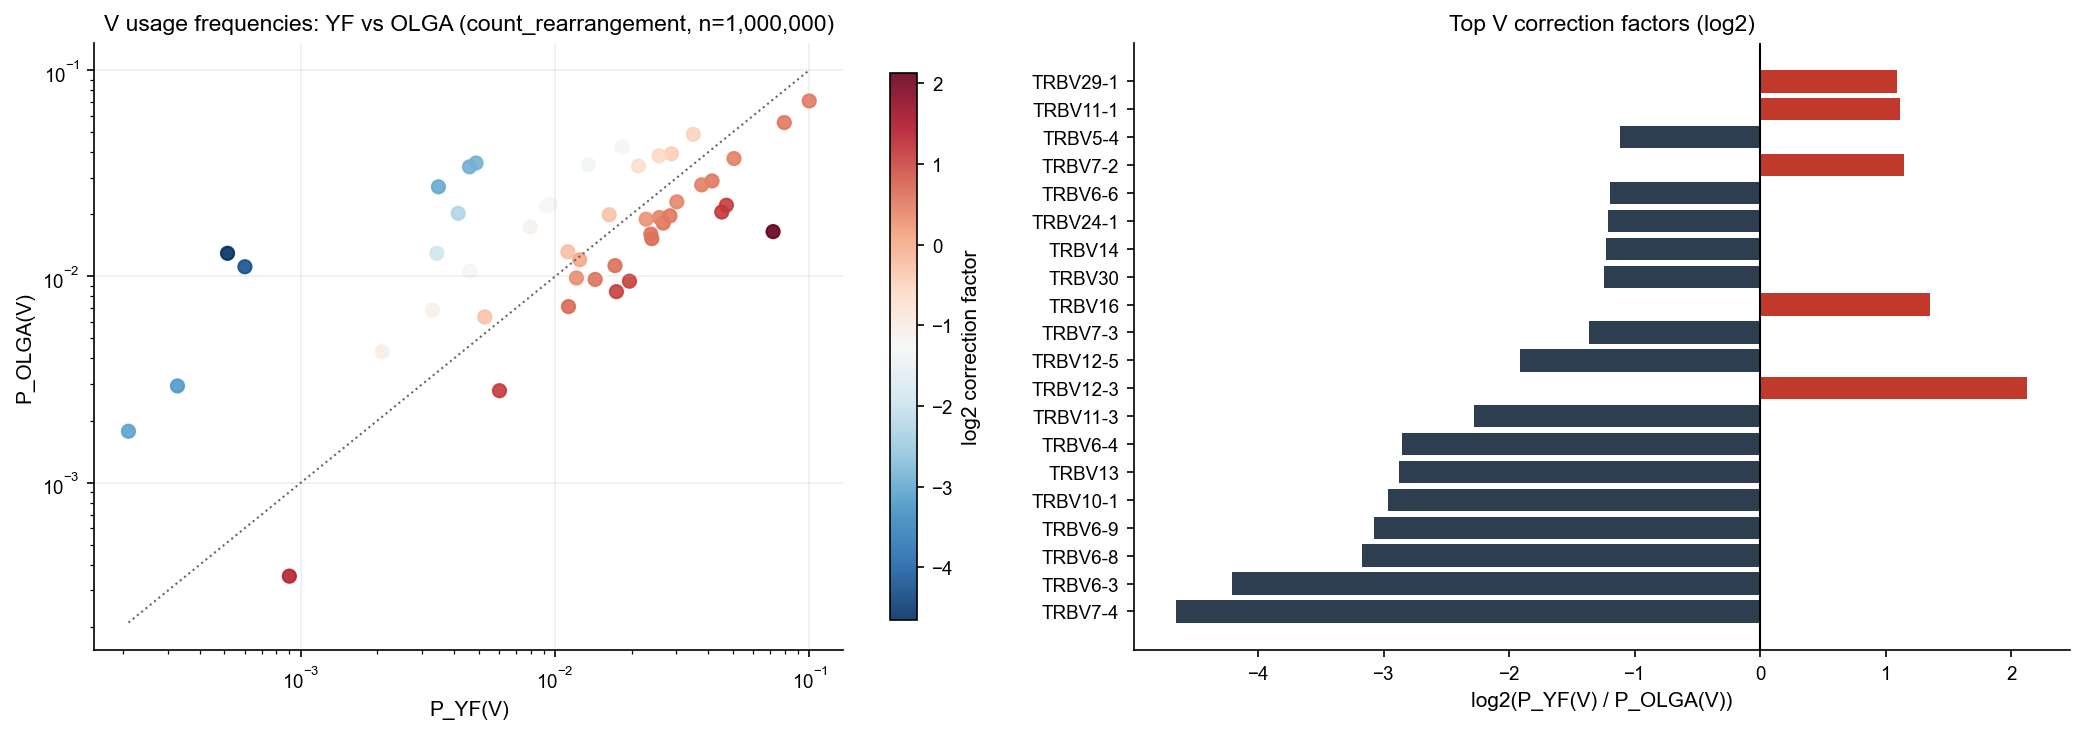

Zero-frequency OLGA V genes in comparison table: 0


In [5]:
usage_result = compute_olga_usage_adjustment(
    yfv_gu,
    seed=SEED,
    n_jobs=8,
    olga_usage_n=OLGA_USAGE_N,
    count_mode=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
)

olga_model = usage_result.olga_model
olga_gu = usage_result.olga_usage
v_cmp = usage_result.v_cmp
vj_cmp = usage_result.vj_cmp
v_df = usage_result.v_df
if hasattr(v_df, "to_pandas"): v_df = v_df.to_pandas()
vj_df = usage_result.vj_df
if hasattr(vj_df, "to_pandas"): vj_df = vj_df.to_pandas()

# Keep OLGA-based adjustment for the synthetic-null comparison section.
pgen_adj_olga = usage_result.pgen_adj_olga

print("Top V genes by |log2 factor|:")
display(v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(15))
print("Top VJ pairs by |log2 factor|:")
display(vj_df.assign(abs_log2=lambda d: d["log2_factor_vj"].abs()).sort_values("abs_log2", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.clip(v_df["p_yf"].values, 1e-12, None)
y = np.clip(v_df["p_olga"].values, 1e-12, None)
sc = axes[0].scatter(x, y, c=v_df["log2_factor_v"].values, cmap="RdBu_r", s=40, alpha=0.9)
axes[0].plot([x.min(), x.max()], [x.min(), x.max()], color="#666666", linestyle=":", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("P_YF(V)")
axes[0].set_ylabel("P_OLGA(V)")
axes[0].set_title(f"V usage frequencies: YF vs OLGA ({USAGE_COUNT_MODE}, n={OLGA_USAGE_N:,})")
axes[0].grid(alpha=0.2)
cb = plt.colorbar(sc, ax=axes[0], shrink=0.9)
cb.set_label("log2 correction factor")

top = v_df.assign(abs_log2=lambda d: d["log2_factor_v"].abs()).sort_values("abs_log2", ascending=False).head(20)
axes[1].barh(top["v_gene"], top["log2_factor_v"], color=["#c0392b" if z > 0 else "#2c3e50" for z in top["log2_factor_v"]])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Top V correction factors (log2)")
axes[1].set_xlabel("log2(P_YF(V) / P_OLGA(V))")

plt.tight_layout()
plt.show()

print(f"Zero-frequency OLGA V genes in comparison table: {(v_df['p_olga'] == 0).sum()}")

### Why real control?

Using a real human TRB control repertoire instead of a fully synthetic OLGA null corrects for biases that OLGA does not model: sequencing depth artifacts, PCR amplification skew, and repertoire sampling effects.

For this section we also compute V/J adjustment against the **real control** distribution (YF / real-control usage), not YF / OLGA. OLGA-based adjustment is kept for the synthetic-null comparison in section 9.

The histogram above should show that the real-control mock bin distribution (blue dashes) is close to the LLW reference (red). A large discrepancy would indicate that Pgen or gene-usage adjustment requires further tuning.

After the mock key sets are built here (lazy, first `.score()` call), each subsequent `.score()` call reuses them — only the query-repertoire counting differs per sample.

Pool built: n_generated=99,981, bins=49, floor=-66, ceil=-18, elapsed=96.8s


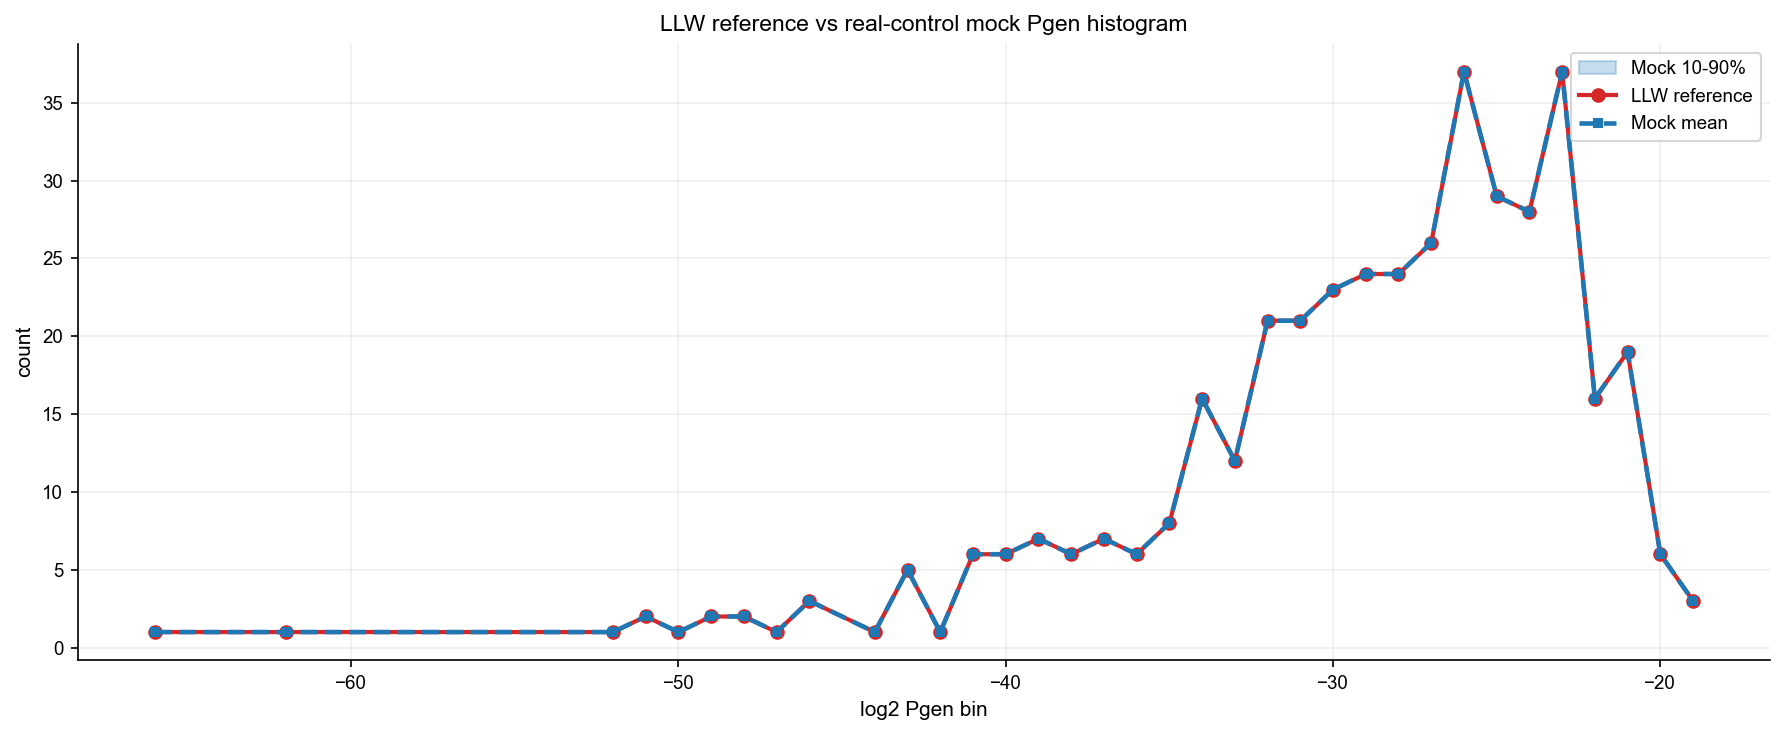

Mock vs LLW: median max|Delta p(bin)|=0.0000, p95=0.0000
Mock vs LLW: median RMSD=0.0000, p95=0.0000


In [6]:
real_result = build_real_control_analysis(
    vdjdb_rep,
    yfv_gu,
    seed=SEED,
    count_mode=USAGE_COUNT_MODE,
    pseudocount=USAGE_PSEUDOCOUNT,
    pool_size=POOL_SIZE,
    n_mocks=N_MOCKS,
    n_jobs=8,
)

real_control_df = real_result.control_df
real_control_gu = real_result.control_usage
pgen_adj_real = real_result.pgen_adj_real
pool = real_result.pool
analysis = real_result.analysis
dt = real_result.elapsed_s
print(f"Pool built: n_generated={pool.n_generated:,}, bins={len(pool.bins)}, floor={pool.floor_bin}, ceil={pool.ceil_bin}, elapsed={dt:.1f}s")

diag = compute_bin_alignment_diagnostics(analysis)
all_bins = diag["all_bins"]
ref_vec = diag["ref_vec"]
mock_mat = diag["mock_mat"]
mock_mean = diag["mock_mean"]
mock_q10 = diag["mock_q10"]
mock_q90 = diag["mock_q90"]
max_abs_diff = diag["max_abs_diff"]
rmsd = diag["rmsd"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(all_bins, mock_q10, mock_q90, alpha=0.25, color="#1f77b4", label="Mock 10-90%", zorder=1)
ax.plot(all_bins, ref_vec, color="#d62728", marker="o", linewidth=2, label="LLW reference", zorder=2)
# Draw mock mean last so it remains visible even when overlapping the reference line.
ax.plot(all_bins, mock_mean, color="#1f77b4", linestyle="--", marker="s", markersize=4, linewidth=2.2, label="Mock mean", zorder=3)
ax.set_xlabel("log2 Pgen bin")
ax.set_ylabel("count")
ax.set_title("LLW reference vs real-control mock Pgen histogram")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Mock vs LLW: median max|Delta p(bin)|={np.median(max_abs_diff):.4f}, p95={np.percentile(max_abs_diff,95):.4f}")
print(f"Mock vs LLW: median RMSD={np.median(rmsd):.4f}, p95={np.percentile(rmsd,95):.4f}")

## 5. LLW overlap per sample: matched clonotypes and duplicate_count

Compute for each donor/day/replica:
- real LLW overlap
- mock distribution summary
- z-score and empirical p-value
- Cohen d
- FDR-adjusted p-values

In [7]:
df_res = score_samples_dataframe(analysis, samples, progress_every=10, sample_n_jobs=8)
# Convert Polars → pandas; downstream cells use pandas API (iterrows, pivot_table, etc.)
if hasattr(df_res, "to_pandas"):
    df_res = df_res.to_pandas()

display(df_res[[
    "donor", "replica", "day",
    "matched_n_real", "matched_dc_real", "matched_n_fraction", "matched_dc_fraction",
    "matched_n_mock_mean", "matched_n_z", "matched_n_p_emp", "matched_n_cohen_d",
    "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_cohen_d",
]])

Processed 10/42 samples


Processed 20/42 samples


Processed 30/42 samples


Processed 40/42 samples


,donor,replica,day,matched_n_real,matched_dc_real,matched_n_fraction,matched_dc_fraction,matched_n_mock_mean,matched_n_z,matched_n_p_emp,matched_n_cohen_d,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_cohen_d
0,P1,F1,-1,11.0,55.0,0.000017,0.000049,21.733,-2.528267,0.999001,-2.528267,5.807355,5.852050,-0.089607,0.525475,-0.089607
1,P1,F1,0,13.0,48.0,0.000022,0.000057,20.682,-1.913755,0.991009,-1.913755,5.614710,5.436454,0.391387,0.355644,0.391387
2,P1,F1,7,21.0,100.0,0.000025,0.000062,27.058,-1.306924,0.931069,-1.306924,6.658211,6.369355,0.581491,0.265734,0.581491
3,P1,F1,15,28.0,364.0,0.000031,0.000206,27.009,0.216564,0.444555,0.216564,8.511753,6.457772,3.232702,0.020979,3.232702
4,P1,F1,45,18.0,432.0,0.000030,0.000452,21.247,-0.767548,0.820180,-0.767548,8.758223,5.732641,5.786307,0.000999,5.786307
5,P1,F2,0,11.0,45.0,0.000021,0.000058,18.572,-1.881685,0.984016,-1.881685,5.523562,5.249873,0.548540,0.305694,0.548540
6,P2,F1,-1,20.0,61.0,0.000019,0.000028,31.375,-2.276396,0.995005,-2.276396,5.954196,6.817136,-1.359797,0.971029,-1.359797
7,P2,F1,0,16.0,41.0,0.000026,0.000042,21.875,-1.380711,0.945055,-1.380711,5.392317,5.736150,-0.618093,0.781219,-0.618093
8,P2,F1,7,29.0,88.0,0.000026,0.000038,30.789,-0.363601,0.673327,-0.363601,6.475733,6.795364,-0.496604,0.714286,-0.496604
9,P2,F1,15,34.0,278.0,0.000029,0.000128,32.486,0.296556,0.422577,0.296556,8.124121,6.744152,2.392145,0.025974,2.392145


### Reading the overlap results

Four metrics are tracked per sample:

- **matched_n_real** — number of unique LLW CDR3+V+J clonotypes found in the sample.
- **matched_dc_real** — sum of `duplicate_count` over those matched clonotypes (read depth of the match).
- **matched_n_fraction** — `matched_n / n_total` (fraction of unique clonotypes in the sample that are LLW).
- **matched_dc_fraction** — `matched_dc / dc_total` (fraction of total read depth contributed by LLW matches).

Z-scores and Cohen d values are computed relative to the real-control mock null; positive values indicate enrichment above expectation.

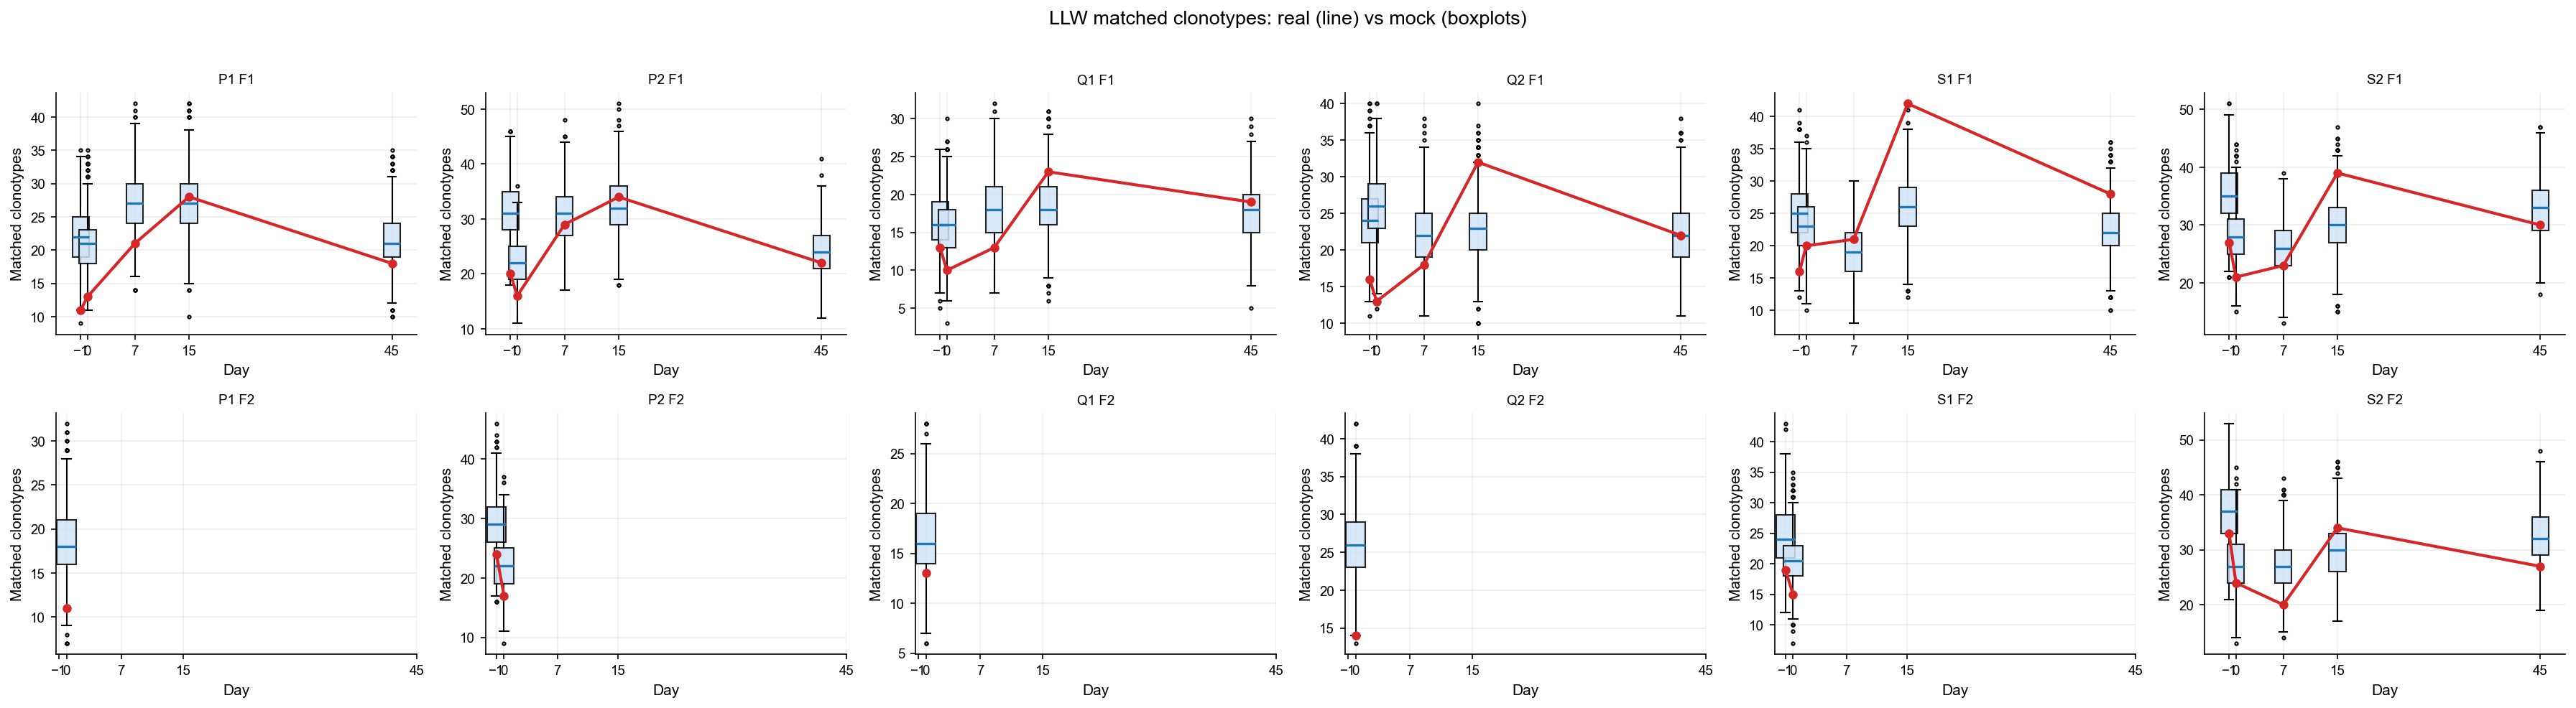

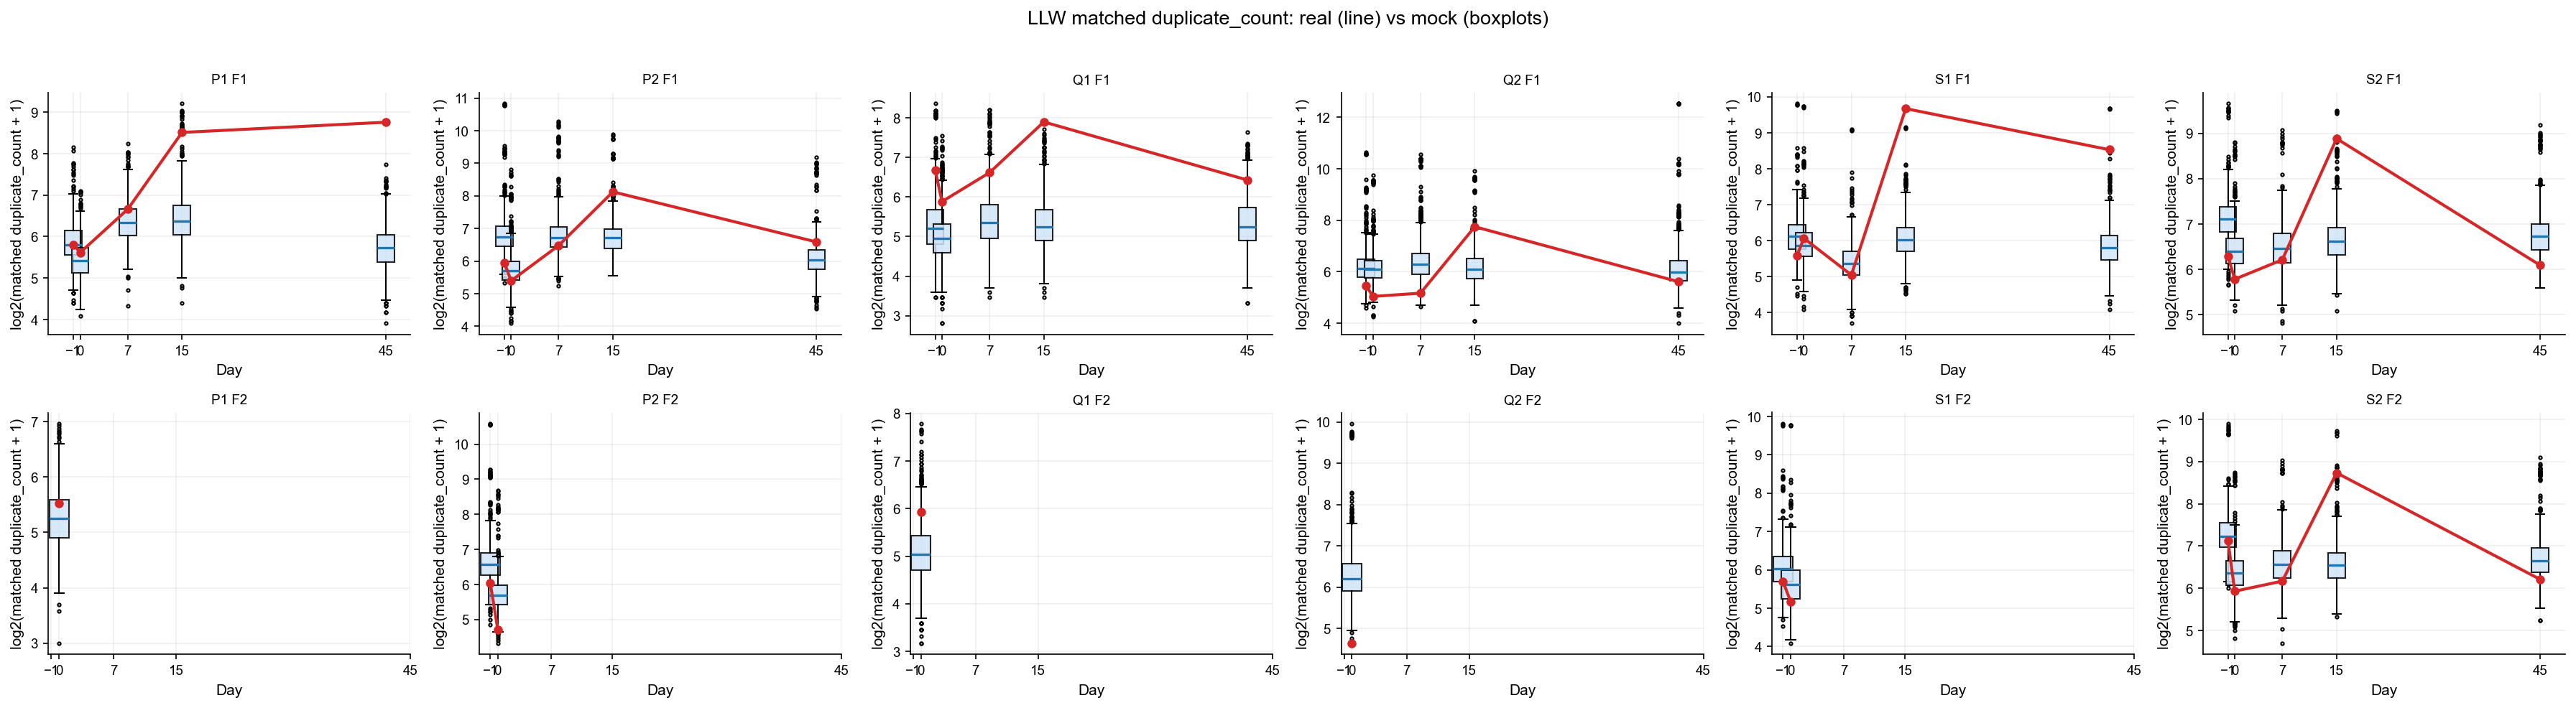

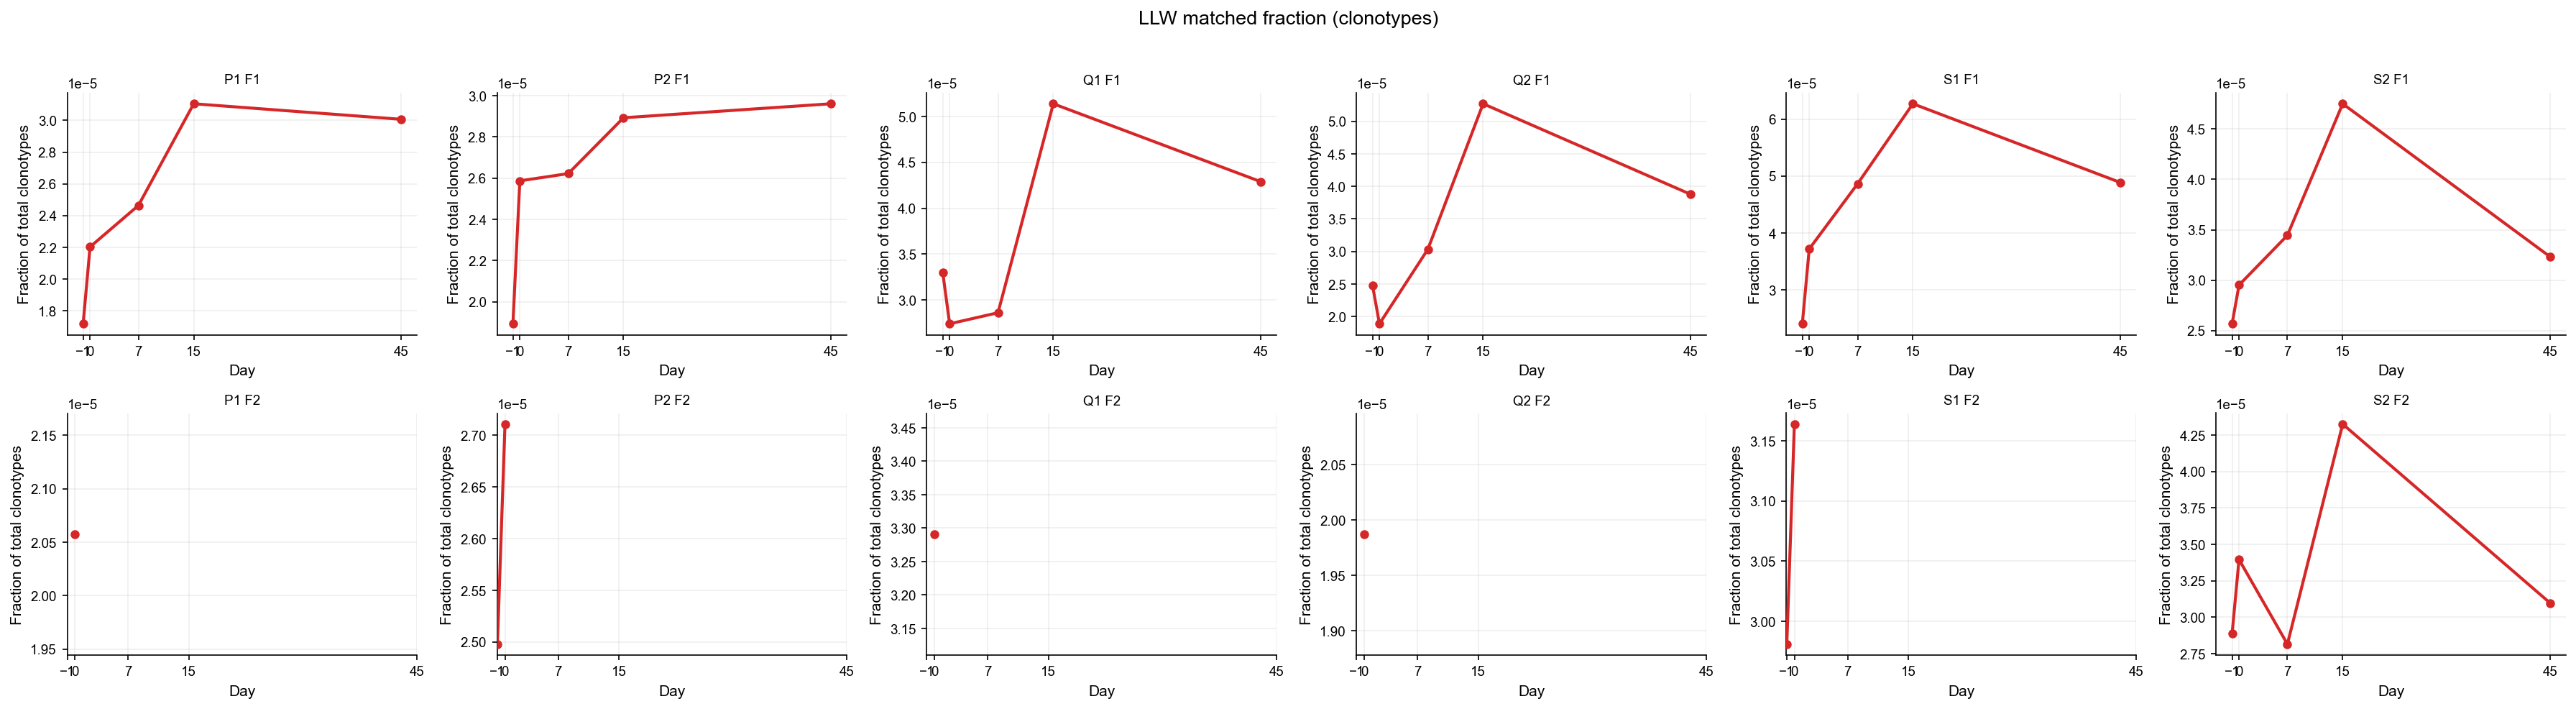

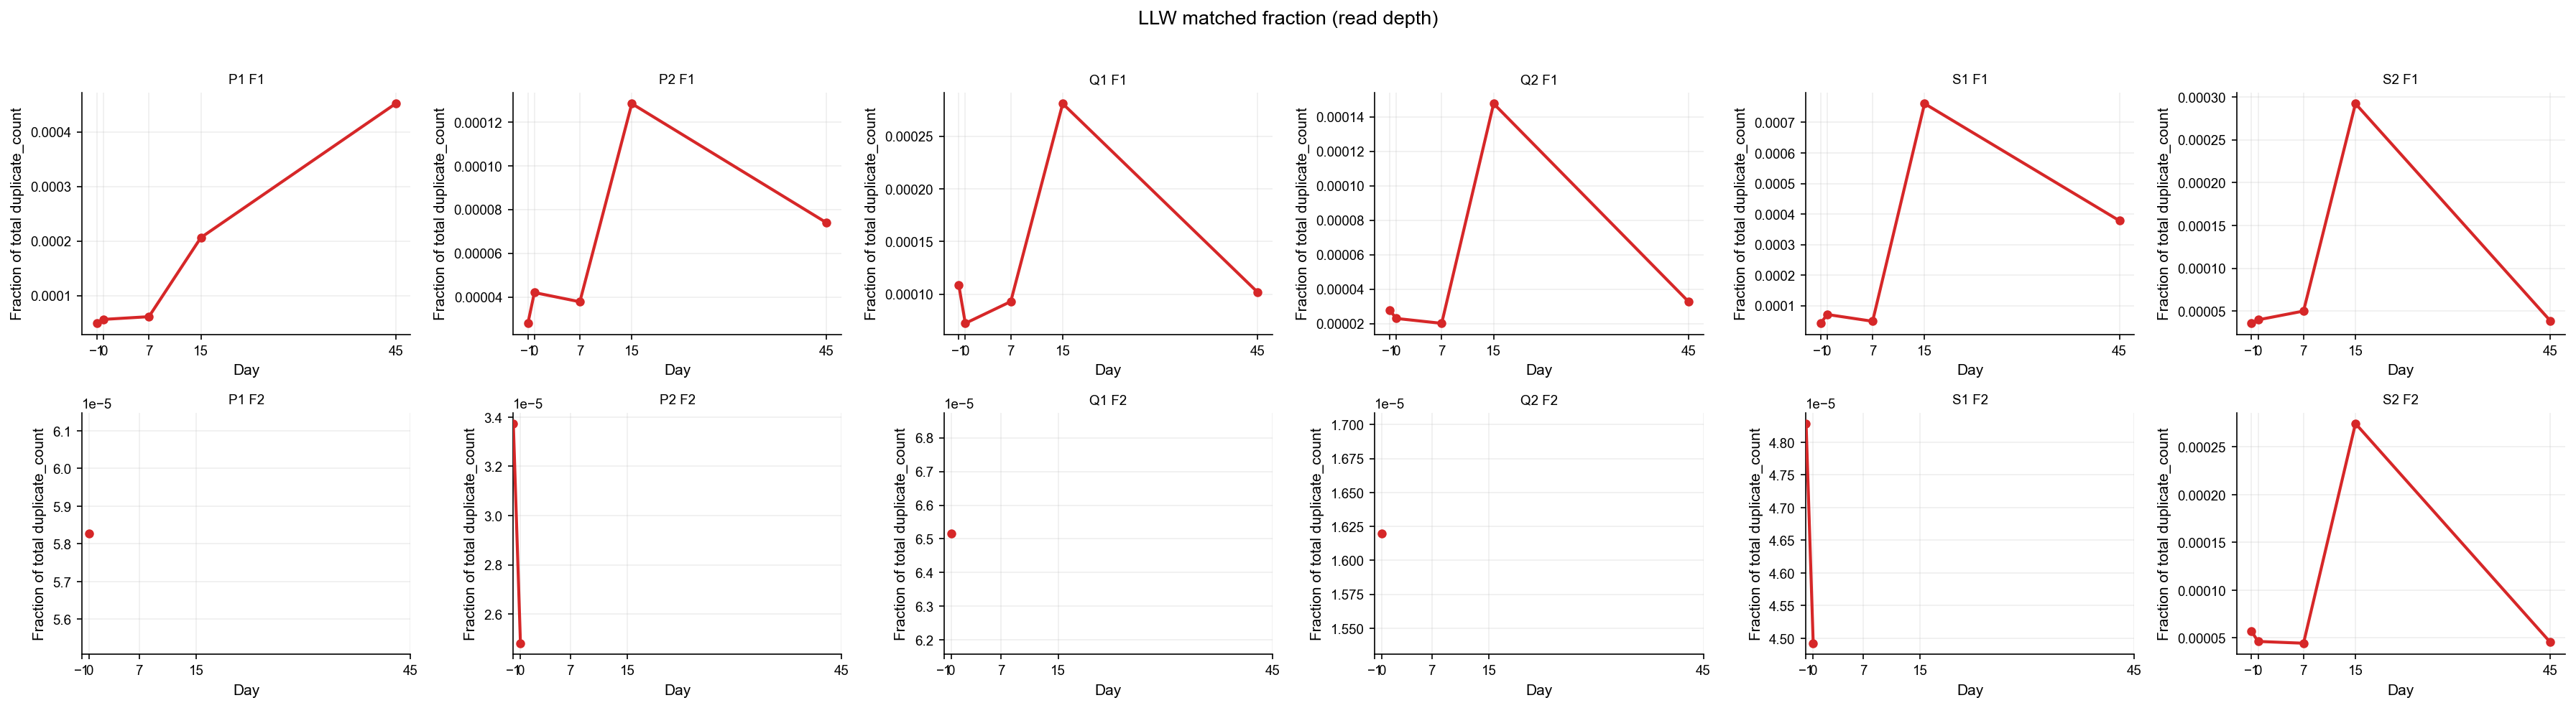

In [8]:
plot_rows = []
for _, r in df_res.iterrows():
    for x in r["mock_n"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_n", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_n", "kind": "real", "value": float(r["matched_n_real"]),
    })
    # Sum of duplicate_count for matched clonotypes (raw read depth of LLW signal)
    for x in r["mock_dc_log2"]:
        plot_rows.append({
            "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
            "metric": "matched_dc_log2", "kind": "mock", "value": float(x),
        })
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_dc_log2", "kind": "real", "value": float(r["matched_dc_log2_real"]),
    })
    # Fraction of unique clonotypes in sample that are LLW-matched
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_n_fraction", "kind": "real", "value": float(r["matched_n_fraction"]),
    })
    # Fraction of total read depth contributed by LLW matches
    plot_rows.append({
        "donor": r["donor"], "replica": r["replica"], "day": int(r["day"]),
        "metric": "matched_dc_fraction", "kind": "real", "value": float(r["matched_dc_fraction"]),
    })

plot_df = pd.DataFrame(plot_rows)
days_all = sorted(df_res["day"].unique().tolist())
donors = sorted(df_res["donor"].unique().tolist())
replicas = sorted(df_res["replica"].unique().tolist())


def draw_panel(metric, ylabel, title, with_mock=True):
    """Draw a grid of per-donor/replica line (real) + optional boxplot (mock) subplots."""
    fig, axes = plt.subplots(
        len(replicas), len(donors),
        figsize=(4.0 * len(donors), 3.2 * len(replicas)),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=13, y=1.02)
    for ri, rep in enumerate(replicas):
        for di, donor in enumerate(donors):
            ax = axes[ri, di]
            sub = plot_df[
                (plot_df["metric"] == metric)
                & (plot_df["donor"] == donor)
                & (plot_df["replica"] == rep)
            ]
            if sub.empty:
                ax.set_visible(False)
                continue

            real = sub[sub["kind"] == "real"].sort_values("day")
            if with_mock:
                mock = sub[sub["kind"] == "mock"]
                box_data = [mock[mock["day"] == d]["value"].values for d in days_all]
                width = 2.5
                ax.boxplot(
                    box_data,
                    positions=days_all,
                    widths=width,
                    patch_artist=True,
                    boxprops=dict(facecolor="#d0e4f7", alpha=0.85),
                    medianprops=dict(color="#1f77b4", linewidth=1.6),
                    flierprops=dict(markersize=2),
                    manage_ticks=False,
                )
            ax.plot(real["day"], real["value"], "-o", color="#d62728", linewidth=2, markersize=5, zorder=5)
            ax.set_xticks(days_all)
            ax.set_xlabel("Day")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{donor} {rep}", fontsize=9)
            ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


draw_panel("matched_n", "Matched clonotypes", "LLW matched clonotypes: real (line) vs mock (boxplots)")
draw_panel("matched_dc_log2", "log2(matched duplicate_count + 1)", "LLW matched duplicate_count: real (line) vs mock (boxplots)")
draw_panel("matched_n_fraction", "Fraction of total clonotypes", "LLW matched fraction (clonotypes)", with_mock=False)
draw_panel("matched_dc_fraction", "Fraction of total duplicate_count", "LLW matched fraction (read depth)", with_mock=False)

## 7. Cohen d heatmaps

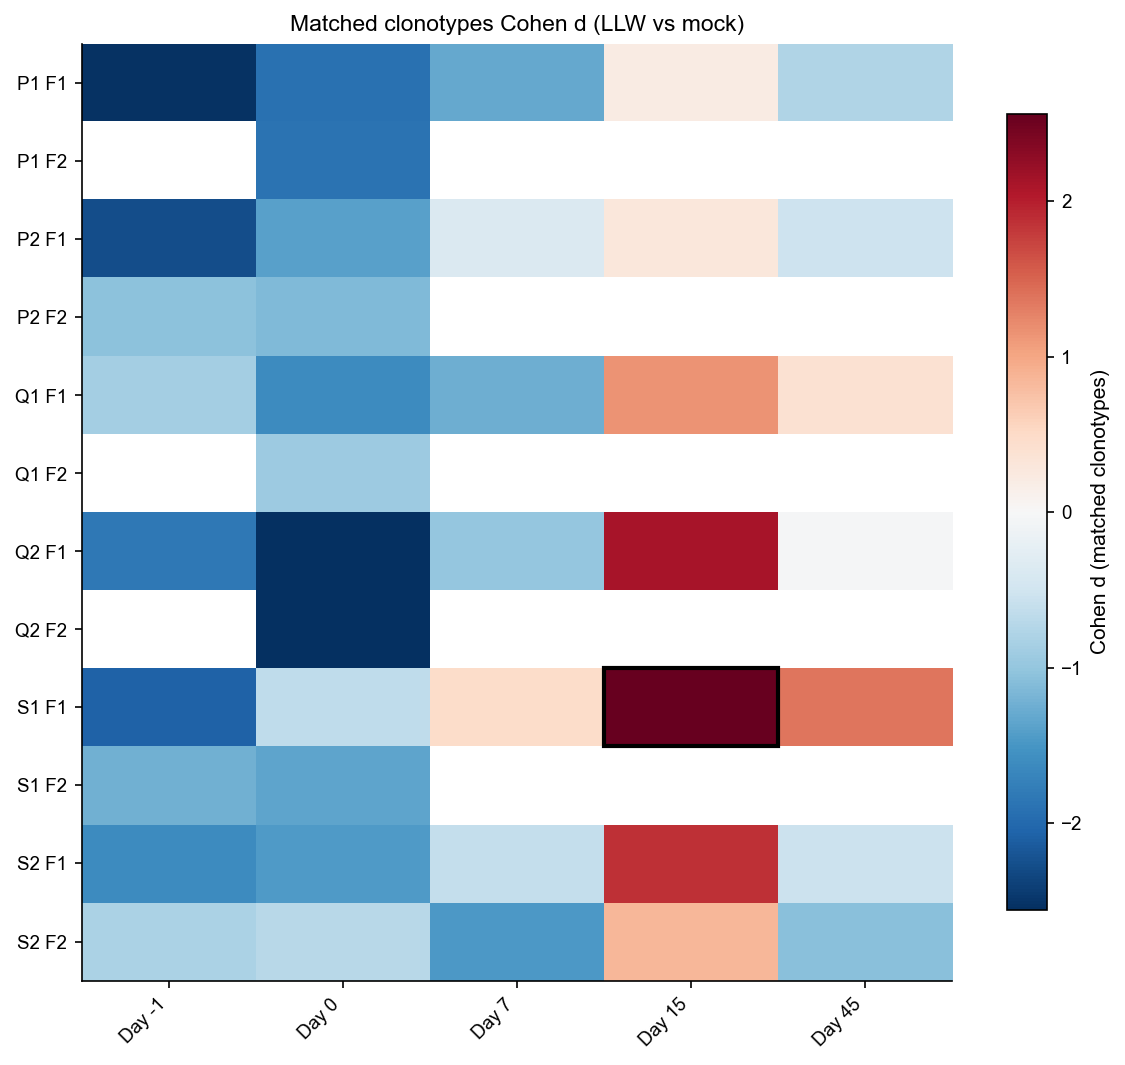

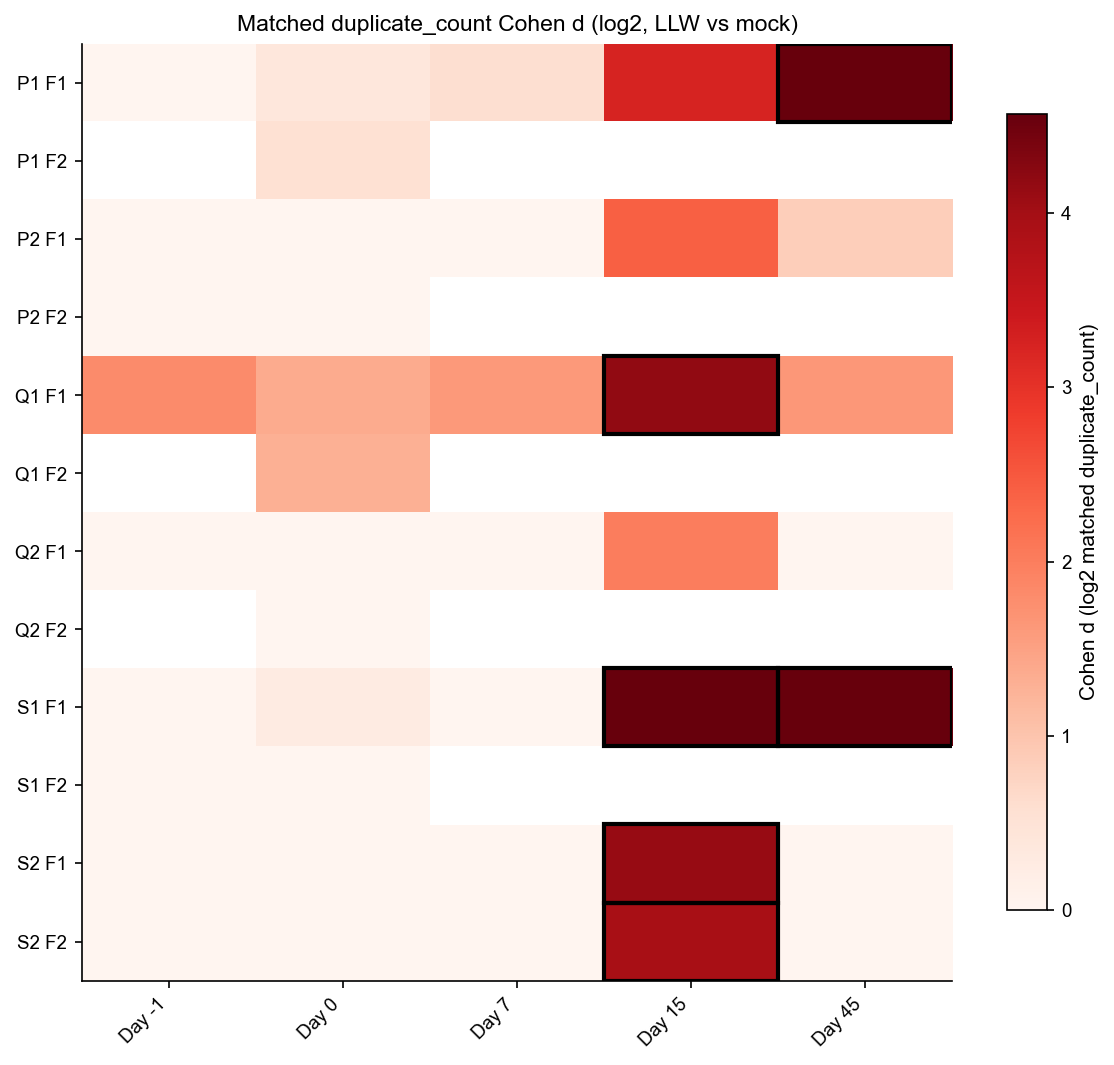

In [9]:
def heatmap_cohen(value_col, p_adj_col, title, cbar_label, cmap="RdBu_r", vlim=None):
    work = df_res.copy()
    work["sample"] = work["donor"] + " " + work["replica"]
    pv = work.pivot_table(index="sample", columns="day", values=value_col, aggfunc="first")
    pp = work.pivot_table(index="sample", columns="day", values=p_adj_col, aggfunc="first")

    mat = pv.values.astype(float)
    if vlim is None:
        vmax = max(1.0, np.nanpercentile(np.abs(mat), 95))
        vmin = -vmax
    else:
        vmin, vmax = vlim

    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.6 * pv.shape[0])))
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax, interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(cbar_label)

    for r in range(pv.shape[0]):
        for c in range(pv.shape[1]):
            p = pp.values[r, c]
            d = pv.values[r, c]
            if pd.notna(p) and pd.notna(d) and (float(p) < 0.10) and (float(d) > 0):
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([f"Day {d}" for d in pv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

heatmap_cohen(
    value_col="matched_n_cohen_d",
    p_adj_col="matched_n_p_adj",
    title="Matched clonotypes Cohen d (LLW vs mock)",
    cbar_label="Cohen d (matched clonotypes)",
    cmap="RdBu_r",
)

heatmap_cohen(
    value_col="matched_dc_log2_cohen_d",
    p_adj_col="matched_dc_log2_p_adj",
    title="Matched duplicate_count Cohen d (log2, LLW vs mock)",
    cbar_label="Cohen d (log2 matched duplicate_count)",
    cmap="Reds",
    vlim=(0, max(1.0, np.nanpercentile(df_res["matched_dc_log2_cohen_d"].values, 95))),
)

## 8. Final summary tables

In [10]:
summary_cols = [
    "donor", "replica", "day",
    "n_total", "dc_total",
    "matched_n_real", "matched_dc_real", "matched_n_fraction", "matched_dc_fraction",
    "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z", "matched_n_p_emp", "matched_n_p_adj",
    "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd",
    "matched_dc_log2_cohen_d", "matched_dc_log2_z", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj",
]
summary = df_res[summary_cols].copy()
for col in [
    "matched_n_real", "matched_dc_real",
    "matched_n_mock_mean", "matched_n_mock_sd", "matched_n_cohen_d", "matched_n_z",
    "matched_dc_log2_real", "matched_dc_log2_mock_mean", "matched_dc_log2_mock_sd", "matched_dc_log2_cohen_d", "matched_dc_log2_z",
]:
    summary[col] = summary[col].astype(float).round(3)
for col in ["matched_n_fraction", "matched_dc_fraction"]:
    summary[col] = summary[col].map(lambda x: f"{x:.5f}")
for col in ["matched_n_p_emp", "matched_n_p_adj", "matched_dc_log2_p_emp", "matched_dc_log2_p_adj"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

display(summary.sort_values(["donor", "replica", "day"]).reset_index(drop=True))

print("Top positive matched clonotype effects by Cohen d:")
display(summary.sort_values("matched_n_cohen_d", ascending=False).head(12))

print("Top positive matched duplicate_count effects by Cohen d:")
display(summary.sort_values("matched_dc_log2_cohen_d", ascending=False).head(12))

,donor,replica,day,n_total,dc_total,matched_n_real,matched_dc_real,matched_n_fraction,matched_dc_fraction,matched_n_mock_mean,...,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
0,P1,F1,-1,640262,1113509,11.0,55.0,0.00002,0.00005,21.733,...,-2.528,0.9990,0.9990,5.807,5.852,0.499,-0.090,-0.090,0.5255,1.0000
1,P1,F1,0,590253,848323,13.0,48.0,0.00002,0.00006,20.682,...,-1.914,0.9910,0.9990,5.615,5.436,0.455,0.391,0.391,0.3556,0.7906
2,P1,F1,7,852394,1623860,21.0,100.0,0.00002,0.00006,27.058,...,-1.307,0.9311,0.9990,6.658,6.369,0.497,0.581,0.581,0.2657,0.6976
3,P1,F1,15,901914,1764263,28.0,364.0,0.00003,0.00021,27.009,...,0.217,0.4446,0.9990,8.512,6.458,0.635,3.233,3.233,0.0210,0.1259
4,P1,F1,45,598677,956614,18.0,432.0,0.00003,0.00045,21.247,...,-0.768,0.8202,0.9990,8.758,5.733,0.523,5.786,5.786,0.0010,0.0140
5,P1,F2,0,534632,772165,11.0,45.0,0.00002,0.00006,18.572,...,-1.882,0.9840,0.9990,5.524,5.250,0.499,0.549,0.549,0.3057,0.7552
6,P2,F1,-1,1056617,2177498,20.0,61.0,0.00002,0.00003,31.375,...,-2.276,0.9950,0.9990,5.954,6.817,0.635,-1.360,-1.360,0.9710,1.0000
7,P2,F1,0,618627,974518,16.0,41.0,0.00003,0.00004,21.875,...,-1.381,0.9451,0.9990,5.392,5.736,0.556,-0.618,-0.618,0.7812,1.0000
8,P2,F1,7,1106211,2324263,29.0,88.0,0.00003,0.00004,30.789,...,-0.364,0.6733,0.9990,6.476,6.795,0.644,-0.497,-0.497,0.7143,1.0000
9,P2,F1,15,1175459,2165475,34.0,278.0,0.00003,0.00013,32.486,...,0.297,0.4226,0.9990,8.124,6.744,0.577,2.392,2.392,0.0260,0.1364


Top positive matched clonotype effects by Cohen d:


,donor,replica,day,n_total,dc_total,matched_n_real,matched_dc_real,matched_n_fraction,matched_dc_fraction,matched_n_mock_mean,...,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,669972,1069012,42.0,814.0,0.00006,0.00076,25.978,...,3.463,0.0010,0.0420,9.671,6.058,0.570,6.332,6.332,0.0010,0.0140
22,Q2,F1,15,607413,1449423,32.0,214.0,0.00005,0.00015,23.039,...,2.116,0.0310,0.6503,7.748,6.201,0.771,2.006,2.006,0.0350,0.1632
35,S2,F1,15,821039,1611965,39.0,471.0,0.00005,0.00029,30.088,...,1.865,0.0470,0.6573,8.883,6.664,0.539,4.117,4.117,0.0060,0.0503
29,S1,F1,45,572955,972623,28.0,368.0,0.00005,0.00038,22.422,...,1.371,0.1099,0.9990,8.527,5.825,0.589,4.589,4.589,0.0040,0.0420
16,Q1,F1,15,447584,843549,23.0,237.0,0.00005,0.00028,18.464,...,1.145,0.1489,0.9990,7.895,5.328,0.616,4.164,4.164,0.0010,0.0140
40,S2,F2,15,786155,1544994,34.0,424.0,0.00004,0.00027,29.750,...,0.842,0.2188,0.9990,8.731,6.590,0.543,3.941,3.941,0.0090,0.0629
27,S1,F1,7,431736,652745,21.0,32.0,0.00005,0.00005,19.118,...,0.477,0.3477,0.9990,5.044,5.401,0.583,-0.612,-0.612,0.7732,1.0000
17,Q1,F1,45,442934,833618,19.0,85.0,0.00004,0.00010,17.543,...,0.397,0.3936,0.9990,6.426,5.341,0.663,1.637,1.637,0.0769,0.2692
9,P2,F1,15,1175459,2165475,34.0,278.0,0.00003,0.00013,32.486,...,0.297,0.4226,0.9990,8.124,6.744,0.577,2.392,2.392,0.0260,0.1364
3,P1,F1,15,901914,1764263,28.0,364.0,0.00003,0.00021,27.009,...,0.217,0.4446,0.9990,8.512,6.458,0.635,3.233,3.233,0.0210,0.1259


Top positive matched duplicate_count effects by Cohen d:


,donor,replica,day,n_total,dc_total,matched_n_real,matched_dc_real,matched_n_fraction,matched_dc_fraction,matched_n_mock_mean,...,matched_n_z,matched_n_p_emp,matched_n_p_adj,matched_dc_log2_real,matched_dc_log2_mock_mean,matched_dc_log2_mock_sd,matched_dc_log2_cohen_d,matched_dc_log2_z,matched_dc_log2_p_emp,matched_dc_log2_p_adj
28,S1,F1,15,669972,1069012,42.0,814.0,0.00006,0.00076,25.978,...,3.463,0.0010,0.0420,9.671,6.058,0.570,6.332,6.332,0.0010,0.0140
4,P1,F1,45,598677,956614,18.0,432.0,0.00003,0.00045,21.247,...,-0.768,0.8202,0.9990,8.758,5.733,0.523,5.786,5.786,0.0010,0.0140
29,S1,F1,45,572955,972623,28.0,368.0,0.00005,0.00038,22.422,...,1.371,0.1099,0.9990,8.527,5.825,0.589,4.589,4.589,0.0040,0.0420
16,Q1,F1,15,447584,843549,23.0,237.0,0.00005,0.00028,18.464,...,1.145,0.1489,0.9990,7.895,5.328,0.616,4.164,4.164,0.0010,0.0140
35,S2,F1,15,821039,1611965,39.0,471.0,0.00005,0.00029,30.088,...,1.865,0.0470,0.6573,8.883,6.664,0.539,4.117,4.117,0.0060,0.0503
40,S2,F2,15,786155,1544994,34.0,424.0,0.00004,0.00027,29.750,...,0.842,0.2188,0.9990,8.731,6.590,0.543,3.941,3.941,0.0090,0.0629
3,P1,F1,15,901914,1764263,28.0,364.0,0.00003,0.00021,27.009,...,0.217,0.4446,0.9990,8.512,6.458,0.635,3.233,3.233,0.0210,0.1259
9,P2,F1,15,1175459,2165475,34.0,278.0,0.00003,0.00013,32.486,...,0.297,0.4226,0.9990,8.124,6.744,0.577,2.392,2.392,0.0260,0.1364
22,Q2,F1,15,607413,1449423,32.0,214.0,0.00005,0.00015,23.039,...,2.116,0.0310,0.6503,7.748,6.201,0.771,2.006,2.006,0.0350,0.1632
13,Q1,F1,-1,393851,930778,13.0,101.0,0.00003,0.00011,16.173,...,-0.864,0.8392,0.9990,6.672,5.294,0.761,1.811,1.811,0.0599,0.2517


Notebook output coverage checklist:

- V usage YF vs OLGA and correction factors
- LLW reference vs mock Pgen histogram alignment
- Matched clonotypes and duplicate_count per sample
- Cohen d, z-scores, empirical p-values, FDR
- Line + boxplot dynamics and Cohen d heatmaps

In [11]:
print("Done: notebook rewritten to Rmd-aligned workflow.")
print(f"Samples: {len(samples)}, mocks: {N_MOCKS}, pool size: {POOL_SIZE:,}")
print("Use the summary table above for export/reporting.")

Done: notebook rewritten to Rmd-aligned workflow.
Samples: 42, mocks: 1000, pool size: 100,000
Use the summary table above for export/reporting.


## 9. Synthetic mock comparison and scale-factor calibration

Sections 1–8 use a **real human TRB control pool** to drive the mock null distribution.
This section builds a complementary **synthetic OLGA pool** and rescores all samples under
that null, then computes a scale factor $X$ aligning the two mean mock overlaps:

$$X = \frac{\bar{m}_{\text{real}}}{\bar{m}_{\text{synth}}}$$

where $\bar{m}$ denotes the mean number of mocked matches across all samples.
Three mock curves are overlaid per day:

- **mock real** — null from the real-control pool (sections 1–8).
- **mock synthetic** — null from OLGA synthetic sequences.
- **mock synthetic × X** — synthetic rescaled to match the real-pool mean.

The scale factor quantifies how much OLGA under- or over-estimates real-sequence
background overlap density.  A value $X > 1$ means the real control finds more
background matches than OLGA predicts (typical due to empirical sequence clustering).

In [12]:
import importlib
import mir.common.control as _ctrl_mod
import mir.comparative.vdjbet as _vdjbet_mod
importlib.reload(_ctrl_mod)
importlib.reload(_vdjbet_mod)
from mir.comparative.vdjbet import PgenBinPool, VDJBetOverlapAnalysis
print('Reloaded mir.common.control and mir.comparative.vdjbet from source')

Reloaded mir.common.control and mir.comparative.vdjbet from source


In [13]:
df_res_real = df_res.copy()  # real-control null from sections 1-8

(
    pool_synth,
    analysis_synth,
    df_res_synth,
    X_scale,
    df_res_synth_scaled,
    ) = build_synthetic_comparison(
        vdjdb_rep,
        samples,
        pgen_adj_olga=pgen_adj_olga,
        pool_size=POOL_SIZE,
        n_mocks=N_MOCKS,
        n_jobs=8,
        seed=SEED,
        sample_n_jobs=8,
        df_res_real=df_res_real,
    )

# Convert Polars → pandas for downstream cells (build_synthetic_comparison returns pl.DataFrame)
if hasattr(df_res_synth, "to_pandas"):
    df_res_synth = df_res_synth.to_pandas()
if hasattr(df_res_synth_scaled, "to_pandas"):
    df_res_synth_scaled = df_res_synth_scaled.to_pandas()

print(f"Synthetic pool records used: {pool_synth.n_generated:,}")
print(f"Synthetic mock mean overlap: {df_res_synth['matched_n_mock_mean'].mean():.4f}")
print(f"Real-control mock mean overlap: {df_res_real['matched_n_mock_mean'].mean():.4f}")
print(f"Scale factor X (real/synthetic): {X_scale:.4f}")

Processed 10/42 samples


Processed 20/42 samples


Processed 30/42 samples


Processed 40/42 samples


Synthetic pool records used: 100,000
Synthetic mock mean overlap: 8.9107
Real-control mock mean overlap: 24.7711
Scale factor X (real/synthetic): 2.7799


In [14]:
# Significant hits under real-control null (from sections 1-8).
sig_n_real = df_res_real[
    (df_res_real["matched_n_p_adj"] < 0.10) & (df_res_real["matched_n_cohen_d"] > 0)
]
sig_dc_real = df_res_real[
    (df_res_real["matched_dc_log2_p_adj"] < 0.10) & (df_res_real["matched_dc_log2_cohen_d"] > 0)
]


def _as_triplet_set(df):
    return {(r.donor, r.replica, int(r.day)) for r in df[["donor", "replica", "day"]].itertuples(index=False)}


def _as_label_list(df):
    return [
        f"{r.donor} {r.replica} day {int(r.day)}"
        for r in df[["donor", "replica", "day"]].itertuples(index=False)
    ]


# Expected significant sets based on the YFV19 Rmd analysis (day 15 peak responders).
expected_sig_n = {("S2", "F1", 15), ("S1", "F1", 15), ("Q2", "F1", 15), ("Q1", "F1", 15)}
expected_sig_dc = {
    ("S2", "F1", 15), ("S2", "F2", 15),
    ("S1", "F1", 15), ("S1", "F1", 45),
    ("Q1", "F1", 15),
    ("P2", "F1", 15),
    ("P1", "F1", 15), ("P1", "F1", 45),
}

set_sig_n = _as_triplet_set(sig_n_real)
set_sig_dc = _as_triplet_set(sig_dc_real)

print("Observed significant matched clonotypes (FDR<0.10, d>0):")
print(_as_label_list(sig_n_real))
print("Observed significant matched duplicate_count log2 (FDR<0.10, d>0):")
print(_as_label_list(sig_dc_real))

print("\nExpectation check: matched clonotypes")
print("match:", set_sig_n == expected_sig_n)
print("missing:", sorted(expected_sig_n - set_sig_n))
print("extra:", sorted(set_sig_n - expected_sig_n))

print("\nExpectation check: matched duplicate_count")
print("match:", set_sig_dc == expected_sig_dc)
print("missing:", sorted(expected_sig_dc - set_sig_dc))
print("extra:", sorted(set_sig_dc - expected_sig_dc))

print(f"\nScale factor X (real/synthetic): {X_scale:.3f}")
print("Observation 1: Real-control null captures empirical sequence clustering that OLGA misses.")
print(f"Observation 2: X = {X_scale:.3f} — synthetic mocks undercount overlap by this factor.")
print("Observation 3: Significant calls are exact junction_aa + V + J matching only.")
print("Observation 4: Compare listed observed sets with target day/sample expectations via missing/extra diagnostics.")

Observed significant matched clonotypes (FDR<0.10, d>0):
['S1 F1 day 15']
Observed significant matched duplicate_count log2 (FDR<0.10, d>0):
['P1 F1 day 45', 'Q1 F1 day 15', 'S1 F1 day 15', 'S1 F1 day 45', 'S2 F1 day 15', 'S2 F2 day 15']

Expectation check: matched clonotypes
match: False
missing: [('Q1', 'F1', 15), ('Q2', 'F1', 15), ('S2', 'F1', 15)]
extra: []

Expectation check: matched duplicate_count
match: False
missing: [('P1', 'F1', 15), ('P2', 'F1', 15)]
extra: []

Scale factor X (real/synthetic): 2.780
Observation 1: Real-control null captures empirical sequence clustering that OLGA misses.
Observation 2: X = 2.780 — synthetic mocks undercount overlap by this factor.
Observation 3: Significant calls are exact junction_aa + V + J matching only.
Observation 4: Compare listed observed sets with target day/sample expectations via missing/extra diagnostics.


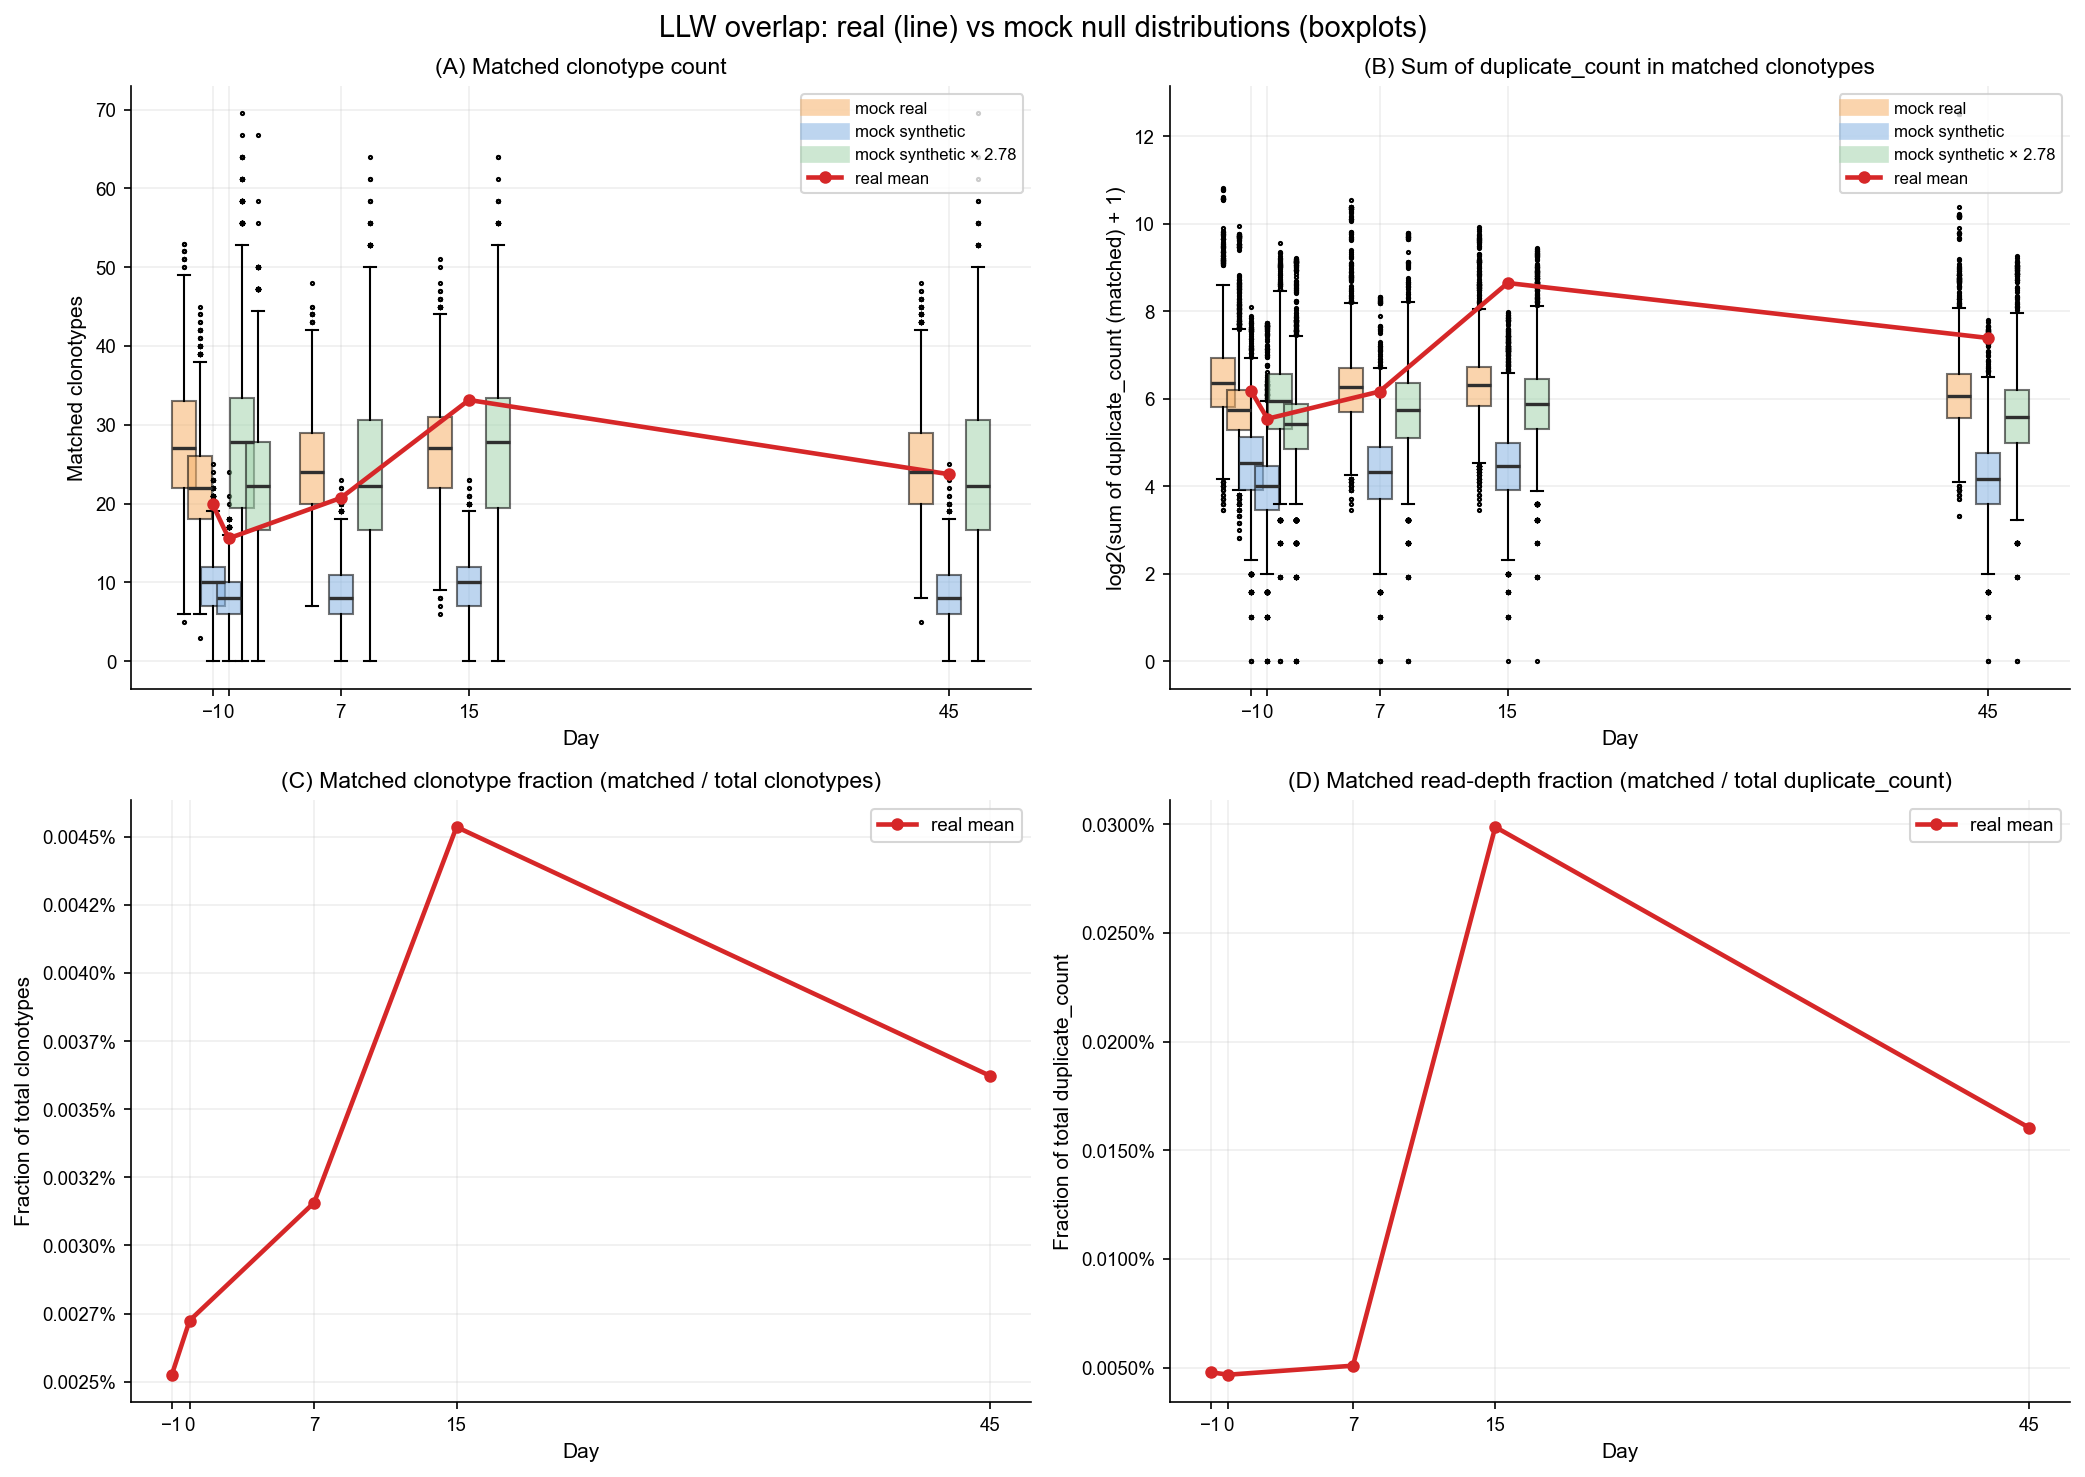

In [15]:
days_plot = sorted(df_res_real["day"].unique().tolist())


def _collect_mock_by_day(df_in, value_col="mock_n", transform=None):
    """Aggregate mock draws per day from a scored DataFrame."""
    out = {d: [] for d in days_plot}
    for _, row in df_in.iterrows():
        d = int(row["day"])
        vals = [float(x) for x in row[value_col]]
        if transform is not None:
            vals = [float(transform(v)) for v in vals]
        out[d].extend(vals)
    return out


real_mock_by_day = _collect_mock_by_day(df_res_real, "mock_n")
syn_mock_by_day = _collect_mock_by_day(df_res_synth, "mock_n")
syn_scaled_mock_by_day = _collect_mock_by_day(df_res_synth_scaled, "mock_n")

# Duplicate-count mock draws are stored as log2(mock_dc + 1). Convert back to raw counts.
_dc_from_log2 = lambda v: (2.0 ** float(v)) - 1.0
real_mock_dc_by_day = _collect_mock_by_day(df_res_real, "mock_dc_log2", transform=_dc_from_log2)
syn_mock_dc_by_day = _collect_mock_by_day(df_res_synth, "mock_dc_log2", transform=_dc_from_log2)
syn_scaled_mock_dc_by_day = _collect_mock_by_day(
    df_res_synth_scaled, "mock_dc_log2", transform=lambda v: _dc_from_log2(v) * X_scale
)

# Real-data mean overlap per day (from sections 1-8, real-control null).
real_mean_by_day = (
    df_res_real.groupby("day", as_index=False)["matched_n_real"].mean().sort_values("day")
)
real_dc_by_day = (
    df_res_real.groupby("day", as_index=False)["matched_dc_real"].mean().sort_values("day")
)
real_frac_n_by_day = (
    df_res_real.groupby("day", as_index=False)["matched_n_fraction"].mean().sort_values("day")
)
real_frac_dc_by_day = (
    df_res_real.groupby("day", as_index=False)["matched_dc_fraction"].mean().sort_values("day")
)

width = 1.5
offsets = [-1.8, 0.0, 1.8]
mock_specs = [
    ("mock real", real_mock_by_day, "#f6b26b", offsets[0]),
    ("mock synthetic", syn_mock_by_day, "#87b4e3", offsets[1]),
    (f"mock synthetic × {X_scale:.2f}", syn_scaled_mock_by_day, "#a4d4ae", offsets[2]),
]
mock_dc_specs = [
    ("mock real", real_mock_dc_by_day, "#f6b26b", offsets[0]),
    ("mock synthetic", syn_mock_dc_by_day, "#87b4e3", offsets[1]),
    (f"mock synthetic × {X_scale:.2f}", syn_scaled_mock_dc_by_day, "#a4d4ae", offsets[2]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("LLW overlap: real (line) vs mock null distributions (boxplots)", fontsize=14)

# ── Panel A: matched clonotype count ──────────────────────────────────────────
ax = axes[0, 0]
for label, by_day, color, off in mock_specs:
    data = [by_day[d] if len(by_day[d]) else [np.nan] for d in days_plot]
    pos = [d + off for d in days_plot]
    ax.boxplot(
        data, positions=pos, widths=width, patch_artist=True, manage_ticks=False,
        boxprops=dict(facecolor=color, alpha=0.55),
        medianprops=dict(color="#2f2f2f", linewidth=1.6),
        flierprops=dict(markersize=1.5),
    )
    ax.plot([], [], color=color, linewidth=8, alpha=0.55, label=label)
ax.plot(real_mean_by_day["day"], real_mean_by_day["matched_n_real"],
        "-o", color="#d62728", linewidth=2.2, markersize=5, label="real mean")
ax.set_xticks(days_plot)
ax.set_xlabel("Day")
ax.set_ylabel("Matched clonotypes")
ax.set_title("(A) Matched clonotype count")
ax.grid(alpha=0.2)
ax.legend(loc="upper right", fontsize=8)

# ── Panel B: sum of duplicate_count in matched clonotypes ─────────────────────
ax = axes[0, 1]
for label, by_day, color, off in mock_dc_specs:
    data_raw = [by_day[d] if len(by_day[d]) else [np.nan] for d in days_plot]
    # Use log2(x + 1) scale for duplicate-count panel.
    data = [np.log2(np.asarray(vals, dtype=float) + 1.0) for vals in data_raw]
    pos = [d + off for d in days_plot]
    ax.boxplot(
        data, positions=pos, widths=width, patch_artist=True, manage_ticks=False,
        boxprops=dict(facecolor=color, alpha=0.55),
        medianprops=dict(color="#2f2f2f", linewidth=1.6),
        flierprops=dict(markersize=1.5),
    )
    ax.plot([], [], color=color, linewidth=8, alpha=0.55, label=label)
ax.plot(
    real_dc_by_day["day"],
    np.log2(real_dc_by_day["matched_dc_real"].astype(float).values + 1.0),
    "-o", color="#d62728", linewidth=2.2, markersize=5, label="real mean"
)
ax.set_xticks(days_plot)
ax.set_xlabel("Day")
ax.set_ylabel("log2(sum of duplicate_count (matched) + 1)")
ax.set_title("(B) Sum of duplicate_count in matched clonotypes")
ax.grid(alpha=0.2)
ax.legend(loc="upper right", fontsize=8)

# ── Panel C: fraction of clonotypes (matched / total) ─────────────────────────
ax = axes[1, 0]
ax.plot(real_frac_n_by_day["day"], real_frac_n_by_day["matched_n_fraction"],
        "-o", color="#d62728", linewidth=2.2, markersize=5, label="real mean")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.4%}"))
ax.set_xticks(days_plot)
ax.set_xlabel("Day")
ax.set_ylabel("Fraction of total clonotypes")
ax.set_title("(C) Matched clonotype fraction (matched / total clonotypes)")
ax.grid(alpha=0.2)
ax.legend()

# ── Panel D: fraction of duplicate_count (matched / total) ────────────────────
ax = axes[1, 1]
ax.plot(real_frac_dc_by_day["day"], real_frac_dc_by_day["matched_dc_fraction"],
        "-o", color="#d62728", linewidth=2.2, markersize=5, label="real mean")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.4%}"))
ax.set_xticks(days_plot)
ax.set_xlabel("Day")
ax.set_ylabel("Fraction of total duplicate_count")
ax.set_title("(D) Matched read-depth fraction (matched / total duplicate_count)")
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()